# Lab 3 Assignment
> Author : Maxence DELEHELLE, Amine SAAD-EDDINE - Data Engineering 1 - ESIEE 2025-2026
**Academic year:** 2025–2026  
**Program:** Data & Applications - Engineering - (FD)   
**Course:** Data Engineering I  
---


## Learning goals
- Analyze with **SQL** and **DataFrames**.
- Implement two **RDD means** variants.
- Implement **RDD joins** (shuffle and hash).
- Record and explain performance observations.


## 1. Setup

Download data files from the following URL:
https://www.dropbox.com/scl/fi/7012u693u06dgj95mgq2a/retail_dw_20250826.tar.gz?rlkey=fxyozuoryn951gzwmli5xi2zd&dl=0

Unpack somewhere and define the `data_path` accordingly:

In [1]:
# Change to path on your local machine.
data_path = "/home/maxence/Documents/data_engineering/assignement/assignement_3/retail_dw_20250826"

In [2]:
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

print("Python utilisé :", sys.executable)
print("Version :", sys.version)

Python utilisé : /home/maxence/miniconda3/envs/de1-env/bin/python
Version : 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


The following cell contains setup to measure wall clock time and memory usage. (Don't worry about the details, just run the cell)

In [3]:
%pip install -U numpy pandas pyarrow matplotlib scipy
import sys, subprocess
try:
    import psutil  # noqa: F401
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "psutil"])
print("psutil is installed.")


from IPython.core.magic import register_cell_magic
import time, os, platform

# Try to import optional modules
try:
    import psutil
except Exception:
    psutil = None

try:
    import resource  # not available on Windows
except Exception:
    resource = None


def _rss_bytes():
    """Resident Set Size in bytes (cross-platform via psutil if available)."""
    if psutil is not None:
        return psutil.Process(os.getpid()).memory_info().rss
    # Fallback: unknown RSS → 0 
    return 0


def _peak_bytes():
    """
    Best-effort peak memory in bytes.
    - Windows: psutil peak working set (peak_wset)
    - Linux:   resource.ru_maxrss (KB → bytes)
    - macOS:   resource.ru_maxrss (bytes)
    Fallback to current RSS if unavailable.
    """
    sysname = platform.system()

    # Windows path: use psutil peak_wset if present
    if sysname == "Windows" and psutil is not None:
        mi = psutil.Process(os.getpid()).memory_info()
        peak = getattr(mi, "peak_wset", None)  # should be available on Windows
        if peak is not None:
            return int(peak)
        return int(mi.rss)

    # POSIX path: resource may be available
    if resource is not None:
        try:
            ru = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            # On Linux ru_maxrss is in kilobytes; on macOS/BSD it is bytes
            if sysname == "Linux":
                return int(ru) * 1024
            else:
                return int(ru)
        except Exception:
            pass

    # Last resort
    return _rss_bytes()


@register_cell_magic
def timemem(line, cell):
    """
    Measure wall time and memory around the execution of this cell.

        %%timemem
        <your code>

    Notes:
    - RSS = resident memory after the cell.
    - Peak is OS-dependent (see _peak_bytes docstring).
    """
    ip = get_ipython()

    rss_before  = _rss_bytes()
    peak_before = _peak_bytes()
    t0 = time.perf_counter()

    # Execute the cell body
    result = ip.run_cell(cell)

    t1 = time.perf_counter()
    rss_after  = _rss_bytes()
    peak_after = _peak_bytes()

    wall = t1 - t0
    rss_delta_mb  = (rss_after  - rss_before)  / (1024 * 1024)
    peak_delta_mb = (peak_after - peak_before) / (1024 * 1024)

    print("======================================")
    print(f"Wall time: {wall:.3f} s")
    print(f"RSS Δ: {rss_delta_mb:+.2f} MB")
    print(f"Peak memory Δ: {peak_delta_mb:+.2f} MB (OS-dependent)")
    print("======================================")

    return result

Note: you may need to restart the kernel to use updated packages.
psutil is installed.


The following code snippet should "just work" to initialize Spark.

In [4]:
import findspark, os, sys

# 1. Path to your Spark installation
os.environ["SPARK_HOME"] = "/home/maxence/Documents/data_engineering/spark-4.0.1-bin-hadoop3"
findspark.init()

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.functions import broadcast

# 2. Capture the Python path of your 'de1' kernel
py = sys.executable 
os.environ["PYSPARK_DRIVER_PYTHON"] = py
os.environ["PYSPARK_PYTHON"] = py

# 3. Build the Session
spark = SparkSession.getActiveSession() or (
    SparkSession.builder
    .appName("A3")
    .master("local[*]")
    .config("spark.driver.memory", "8g")           
    .config("spark.sql.shuffle.partitions","400")
    .config("spark.sql.adaptive.enabled", "true")
    # --- FIX FOR THE LOG ERROR ---
    .config("spark.eventLog.enabled", "false") 
    # -----------------------------
    .config("spark.pyspark.driver.python", py)
    .config("spark.pyspark.python", py)
    .config("spark.executorEnv.PYSPARK_PYTHON", py)
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
sc = spark.sparkContext

print("Spark version:", spark.version)
print("Python used by Spark:", py)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/27 11:35:09 WARN Utils: Your hostname, maxence-HP-Laptop-14s-dq2xxx, resolves to a loopback address: 127.0.1.1; using 192.168.1.30 instead (on interface wlo1)
25/12/27 11:35:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/27 11:35:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/27 11:35:11 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.0.1
Python used by Spark: /home/maxence/miniconda3/envs/de1-env/bin/python


## 2. Loading DataFrames

Let's load the DataFrames and print out their schemas:

In [5]:
# Note that you should have defined data_path above

events_df   = spark.read.parquet(os.path.join(data_path, "retail_dw_20250826_events"))
products_df = spark.read.parquet(os.path.join(data_path, "retail_dw_20250826_products"))
brands_df   = spark.read.parquet(os.path.join(data_path, "retail_dw_20250826_brands"))

events_df.printSchema()
products_df.printSchema()
brands_df.printSchema()

root
 |-- date_key: integer (nullable = true)
 |-- user_key: integer (nullable = true)
 |-- age_key: integer (nullable = true)
 |-- product_key: integer (nullable = true)
 |-- brand_key: integer (nullable = true)
 |-- category_key: integer (nullable = true)
 |-- session_id: string (nullable = true)
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- price: double (nullable = true)

root
 |-- category_code: string (nullable = true)
 |-- brand_code: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- product_desc: string (nullable = true)
 |-- brand_key: integer (nullable = true)
 |-- category_key: integer (nullable = true)
 |-- product_key: integer (nullable = true)

root
 |-- brand_code: string (nullable = true)
 |-- brand_desc: string (nullable = true)
 |-- brand_key: integer (nullable = true)



How many rows are in each table?

In [6]:
print(f"Number of rows in events   table: {events_df.count()}")
print(f"Number of rows in products table: {products_df.count()}")
print(f"Number of rows in brands   table: {brands_df.count()}")

Number of rows in events   table: 42351862
Number of rows in products table: 166794
Number of rows in brands   table: 3444


We can register the DataFrames as tables and issue SQL queries:

In [7]:
events_df.createOrReplaceTempView("events")
products_df.createOrReplaceTempView("products")
brands_df.createOrReplaceTempView("brands")

spark.sql('select count(*) from events').show()
spark.sql('select count(*) from products').show()
spark.sql('select count(*) from brands').show()

+--------+
|count(1)|
+--------+
|42351862|
+--------+

+--------+
|count(1)|
+--------+
|  166794|
+--------+

+--------+
|count(1)|
+--------+
|    3444|
+--------+



As a sanity check, the corresponding values should match: counting the rows in the DataFrame vs. issuing an SQL query to count the number of rows.

## 3. Data Science

Answer Q1 to Q7 below with SQL queries and DataFrame manipulations.

**write some code here**

### 3.1 Q1

For session_id `789d3699-028e-4367-b515-b82e2cb5225f`, what was the purchase price?

**Hint:** We only care about purchase events.

First, do it using SQL:

In [8]:
%%timemem
# codecell_31a (keep this id for tracking purposes)

# Write your SQL below
sql_query = f"""

SELECT price 
FROM events 
WHERE session_id = '789d3699-028e-4367-b515-b82e2cb5225f' 
  AND event_type = 'purchase'
  
"""

results = spark.sql(sql_query)

results.show()


[Stage 23:================================>                        (9 + 7) / 16]



+------+
| price|
+------+
|100.39|
+------+

Wall time: 2.030 s
RSS Δ: +0.02 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7c1d473d0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7c1d47310, raw_cell="# codecell_31a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [9]:
%%timemem
# codecell_31b (keep this id for tracking purposes)

# TODO: Write your code below, but do not remove any lines already in this cell.

results_df = events_df.filter(
    (F.col("session_id") == "789d3699-028e-4367-b515-b82e2cb5225f") & 
    (F.col("event_type") == "purchase")
).select("price")

results_df.show()

+------+
| price|
+------+
|100.39|
+------+

Wall time: 1.075 s
RSS Δ: +0.03 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad78809bf10, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad78809bb20, raw_cell="# codecell_31b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.2 Q2

How many products are sold by the brand "sokolov"?

First, do it using SQL:

In [10]:
%%timemem
# codecell_32a (keep this id for tracking purposes)

# Write your SQL below
sql_query = f"""

SELECT count(DISTINCT e.product_key) as nb_products
FROM events e
JOIN brands b ON e.brand_key = b.brand_key
WHERE b.brand_code = 'sokolov' 
  AND e.event_type = 'purchase'
  
"""

results = spark.sql(sql_query)

results.show()

+-----------+
|nb_products|
+-----------+
|        354|
+-----------+

Wall time: 1.990 s
RSS Δ: +0.02 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7c1d46950, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7c1d45e70, raw_cell="# codecell_32a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [11]:
%%timemem
# codecell_32b (keep this id for tracking purposes)

# TODO: Write your code below, but do not remove any lines already in this cell.

results_df = events_df.join(brands_df, "brand_key") \
    .filter((F.col("brand_code") == "sokolov") & (F.col("event_type") == "purchase")) \
    .select(F.countDistinct("product_key").alias("nb_products"))

results_df.show()

+-----------+
|nb_products|
+-----------+
|        354|
+-----------+

Wall time: 1.316 s
RSS Δ: +0.02 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad78809bd60, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad78809be50, raw_cell="# codecell_32b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.3 Q3

What is the average purchase price of items purchased from the brand "febest"? (Report answer to two digits after the decimal point, i.e., XX.XX.)

First, do it using SQL:

In [12]:
%%timemem
# codecell_33a (keep this id for tracking purposes)

# Write your SQL below
sql_query = f"""

SELECT ROUND(AVG(e.price), 2) as avg_price
FROM events e
JOIN brands b ON e.brand_key = b.brand_key
WHERE b.brand_code = 'febest' 
  AND e.event_type = 'purchase'
  
"""

results = spark.sql(sql_query)

results.show()

+---------+
|avg_price|
+---------+
|    20.39|
+---------+

Wall time: 1.252 s
RSS Δ: +0.02 MB
Peak memory Δ: +0.00 MB (OS-dependent)



[Stage 42:=============================================>          (17 + 4) / 21]



<ExecutionResult object at 7ad7880ed000, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7c1d470d0, raw_cell="# codecell_33a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [13]:
%%timemem
# codecell_33b (keep this id for tracking purposes)

# TODO: Write your code below, but do not remove any lines already in this cell.

results_df = events_df.join(brands_df, "brand_key") \
    .filter((F.col("brand_code") == "febest") & (F.col("event_type") == "purchase")) \
    .select(F.round(F.avg("price"), 2).alias("avg_price"))

results_df.show()


[Stage 46:=====================>                                   (8 + 8) / 21]



+---------+
|avg_price|
+---------+
|    20.39|
+---------+

Wall time: 1.051 s
RSS Δ: +0.03 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7880edbd0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7880ef130, raw_cell="# codecell_33b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.4 Q4

What is the average number of events per user? (Report answer to two digits after the decimal point, i.e., XX.XX.)

First, do it using SQL:

In [14]:
%%timemem
# codecell_34a (keep this id for tracking purposes)

# Write your SQL below
sql_query = f"""

SELECT ROUND(AVG(event_count), 2) as avg_events_per_user
FROM (
    SELECT user_key, count(*) as event_count 
    FROM events 
    GROUP BY user_key
)

"""

results = spark.sql(sql_query)

results.show()

+-------------------+
|avg_events_per_user|
+-------------------+
|              14.02|
+-------------------+

Wall time: 2.546 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7880ed720, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7880ee3b0, raw_cell="# codecell_34a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [15]:
%%timemem
# codecell_34b (keep this id for tracking purposes)

# TODO: Write your code below, but do not remove any lines already in this cell.

user_counts = events_df.groupBy("user_key").count()
results_df = user_counts.select(F.round(F.avg("count"), 2).alias("avg_events_per_user"))

results_df.show()


[Stage 55:=====================>                                   (8 + 8) / 21]



+-------------------+
|avg_events_per_user|
+-------------------+
|              14.02|
+-------------------+

Wall time: 1.428 s
RSS Δ: +0.01 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7880eca00, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7880ee440, raw_cell="# codecell_34b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.5 Q5

What are the top 10 (`product_name`, `brand_code`) pairs in terms of revenue? We want the answer rows sorted by revenue in descending order.

First, do it using SQL:

In [16]:
%%timemem
# codecell_35a (keep this id for tracking purposes)

# Write your SQL below
sql_query = f"""

SELECT p.product_name, b.brand_code, SUM(e.price) as total_revenue
FROM events e
JOIN products p ON e.product_key = p.product_key
JOIN brands b ON e.brand_key = b.brand_key
WHERE e.event_type = 'purchase'
GROUP BY p.product_name, b.brand_code
ORDER BY total_revenue DESC
LIMIT 10

"""

results = spark.sql(sql_query)

results.show()

+---------------+----------+--------------------+
|   product_name|brand_code|       total_revenue|
+---------------+----------+--------------------+
|     smartphone|     apple| 1.671134080299983E8|
|     smartphone|   samsung|  9.54662750799999E7|
|     smartphone|    xiaomi|2.2549726339999955E7|
|     smartphone|    huawei| 1.363398708999999E7|
|       video.tv|   samsung|1.2209992470000006E7|
|           NULL|   lucente|   9556989.319999998|
|       notebook|      acer|   8963128.649999993|
|         clocks|     apple|   8622900.639999997|
|audio.headphone|     apple|   7783503.129999984|
| kitchen.washer|   samsung|   5779978.030000006|
+---------------+----------+--------------------+

Wall time: 2.159 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7880ec880, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7880ee710, raw_cell="# codecell_35a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [17]:
%%timemem
# codecell_35b (keep this id for tracking purposes)

# TODO: Write your code below, but do not remove any lines already in this cell.

results_df = events_df.filter(F.col("event_type") == "purchase") \
    .join(products_df.select("product_key", "product_name"), "product_key") \
    .join(brands_df.select("brand_key", "brand_code"), "brand_key") \
    .groupBy("product_name", "brand_code") \
    .agg(F.sum("price").alias("total_revenue")) \
    .orderBy(F.col("total_revenue").desc()) \
    .limit(10)

results_df.show(truncate=False)

+---------------+----------+--------------------+
|product_name   |brand_code|total_revenue       |
+---------------+----------+--------------------+
|smartphone     |apple     |1.671134080299983E8 |
|smartphone     |samsung   |9.54662750799999E7  |
|smartphone     |xiaomi    |2.2549726339999955E7|
|smartphone     |huawei    |1.363398708999999E7 |
|video.tv       |samsung   |1.2209992470000006E7|
|NULL           |lucente   |9556989.319999998   |
|notebook       |acer      |8963128.649999993   |
|clocks         |apple     |8622900.639999997   |
|audio.headphone|apple     |7783503.129999984   |
|kitchen.washer |samsung   |5779978.030000006   |
+---------------+----------+--------------------+

Wall time: 1.894 s
RSS Δ: -0.47 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad78809ba90, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad788099c00, raw_cell="# codecell_35b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

### 3.6 Q6

Tally up counts of events by hour.
More precisely, we want a table with hours 0, 1, ... 23 with the counts of events in that hour.

First, do it using SQL:

In [18]:
%%timemem
# codecell_36a (keep this id for tracking purposes)

# Write your SQL below
sql_query = f"""

SELECT hour(event_time) as hour, count(*) as count
FROM events
GROUP BY hour
ORDER BY hour

"""

results = spark.sql(sql_query)

results.show(24)

+----+-------+
|hour|  count|
+----+-------+
|   0| 263808|
|   1| 223635|
|   2| 353509|
|   3| 623434|
|   4|1137209|
|   5|1605037|
|   6|1955461|
|   7|2131930|
|   8|2269469|
|   9|2332649|
|  10|2380185|
|  11|2335494|
|  12|2282992|
|  13|2181477|
|  14|2171196|
|  15|2407266|
|  16|2717710|
|  17|2988054|
|  18|3008559|
|  19|2631424|
|  20|1999466|
|  21|1244129|
|  22| 694728|
|  23| 413041|
+----+-------+

Wall time: 1.902 s
RSS Δ: -44.38 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7880ee740, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7880eee60, raw_cell="# codecell_36a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [19]:
%%timemem
# codecell_36b (keep this id for tracking purposes)

# TODO: Write your code below, but do not remove any lines already in this cell.

events_by_hour_df = events_df.withColumn("hour", F.hour("event_time")) \
    .groupBy("hour") \
    .count() \
    .orderBy("hour")

events_by_hour_df.show(24)

+----+-------+
|hour|  count|
+----+-------+
|   0| 263808|
|   1| 223635|
|   2| 353509|
|   3| 623434|
|   4|1137209|
|   5|1605037|
|   6|1955461|
|   7|2131930|
|   8|2269469|
|   9|2332649|
|  10|2380185|
|  11|2335494|
|  12|2282992|
|  13|2181477|
|  14|2171196|
|  15|2407266|
|  16|2717710|
|  17|2988054|
|  18|3008559|
|  19|2631424|
|  20|1999466|
|  21|1244129|
|  22| 694728|
|  23| 413041|
+----+-------+

Wall time: 1.623 s
RSS Δ: +0.01 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7880ee290, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7880efaf0, raw_cell="# codecell_36b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

When you run the cell above, `events_by_hour_df` should be something like:

```
+----+-------+
|hour|  count|
+----+-------+
|   0|    ???|
|   1|    ???|
  ...
|  23|    ???|
+----+-------+
```

Now plot the above DataFrame using `matplotlib`.
Here we want a line graph, with hour on the _x_ axis and count on the _y_ axis.

**Hint:** use the code below to get started.

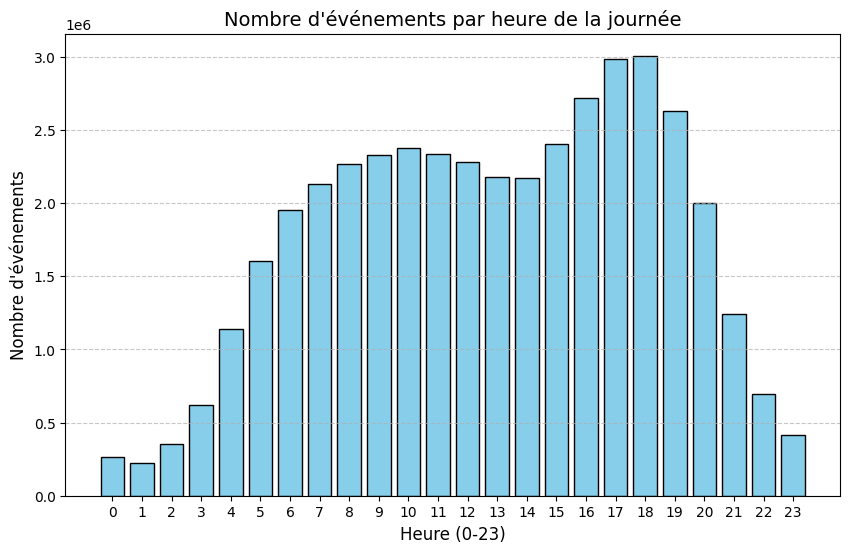

Wall time: 2.411 s
RSS Δ: +37.19 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7880eeda0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7880ef9d0, raw_cell="# codecell_36c (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [20]:
%%timemem
# codecell_36c (keep this id for tracking purposes)

import matplotlib.pyplot as plt

events_by_hour_pdf = events_by_hour_df.toPandas()

# TODO: Write your code below, but do not remove any lines already in this cell.
plt.figure(figsize=(10, 6))
plt.bar(events_by_hour_pdf['hour'], events_by_hour_pdf['count'], color='skyblue', edgecolor='black')

plt.title("Nombre d'événements par heure de la journée", fontsize=14)
plt.xlabel("Heure (0-23)", fontsize=12)
plt.ylabel("Nombre d'événements", fontsize=12)
plt.xticks(range(0, 24)) # Pour afficher toutes les heures sur l'axe X
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### 3.7 Q7

We are going to analyze the "big" brands. Find out the average purchase price by brand, and restrict to cases where the average is more than 10K.
We want the results sorted by the average purchase price from the largest to smallest value.
(Report answers to two digits after the decimal point, i.e., XX.XX, but it's okay if the output only contains one digit after the decimal point.)

First, do it using SQL:

In [21]:
%%timemem
# codecell_37a (keep this id for tracking purposes)

# Write your SQL below
sql_query = f"""

SELECT b.brand_code, ROUND(AVG(e.price), 2) as avg_price
FROM events e
JOIN brands b ON e.brand_key = b.brand_key
WHERE e.event_type = 'purchase'
GROUP BY b.brand_code
HAVING avg_price > 10000
ORDER BY avg_price DESC

"""

results = spark.sql(sql_query)

results.show()

+----------+---------+
|brand_code|avg_price|
+----------+---------+
|      adam|  58946.0|
|      kona|  43759.0|
|  yuandong|  35329.0|
|   bentley|  23164.0|
|      otex| 18633.14|
|    suunto| 10732.82|
|     stark| 10400.25|
+----------+---------+

Wall time: 1.554 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7880ef250, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7880ec220, raw_cell="# codecell_37a (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

Next, do it with DataFrames:

In [22]:
%%timemem
# codecell_37b (keep this id for tracking purposes)

# TODO: Write your code below, but do not remove any lines already in this cell.

avg_price_by_brand_df = events_df.filter(F.col("event_type") == "purchase") \
    .join(brands_df.select("brand_key", "brand_code"), "brand_key") \
    .groupBy("brand_code") \
    .agg(F.round(F.avg("price"), 2).alias("avg_price")) \
    .filter(F.col("avg_price") > 10000) \
    .orderBy(F.col("avg_price").desc())


avg_price_by_brand_df.show()


[Stage 90:=====================>                                   (8 + 8) / 21]



+----------+---------+
|brand_code|avg_price|
+----------+---------+
|      adam|  58946.0|
|      kona|  43759.0|
|  yuandong|  35329.0|
|   bentley|  23164.0|
|      otex| 18633.14|
|    suunto| 10732.82|
|     stark| 10400.25|
+----------+---------+

Wall time: 1.226 s
RSS Δ: +0.05 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad782538520, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad78253ab60, raw_cell="# codecell_37b (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

When you run the cell above, `avg_price_by_brand_df` should be something like:

```
+----------+------------------+
|brand_code|         avg_price|
+----------+------------------+
|       ???|               ???|
        ...
|       ???|               ???|
+----------+------------------+
```

Now plot the above DataFrame using `matplotlib`.
Here we want a bar chart, with each of the brands as a bar, and the average price on the _y_ axis.

**Hint:** use the code below to get started.

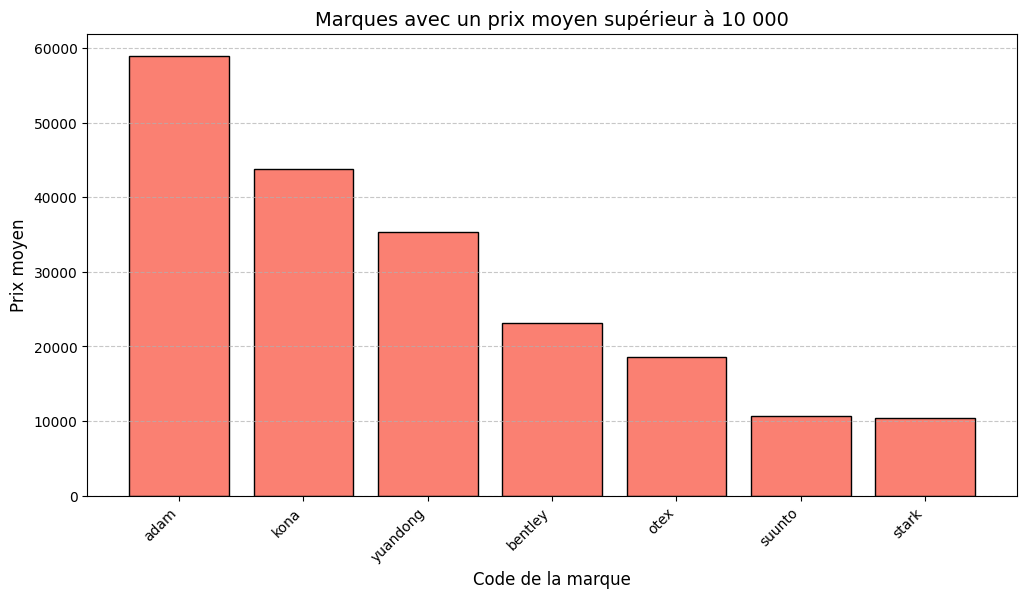

Wall time: 1.464 s
RSS Δ: +3.73 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad781f669b0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad781f66980, raw_cell="# codecell_37c (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=None>

In [23]:
%%timemem
# codecell_37c (keep this id for tracking purposes)

import matplotlib.pyplot as plt

avg_price_by_brand_pdf = avg_price_by_brand_df.toPandas()

# TODO: Write your code below, but do not remove any lines already in this cell.

plt.figure(figsize=(12, 6))
df_sorted = avg_price_by_brand_pdf.sort_values('avg_price', ascending=False)

plt.bar(df_sorted['brand_code'], df_sorted['avg_price'], color='salmon', edgecolor='black')

plt.title("Marques avec un prix moyen supérieur à 10 000", fontsize=14)
plt.xlabel("Code de la marque", fontsize=12)
plt.ylabel("Prix moyen", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotation des noms pour la lisibilité
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## 4. Load RDDs

The remaining exercises focus on RDD manipulations.

Let's start by loading the RDDs.

In [24]:
# Get RDDs directly from DataFrames (with required repartitions)
# type: RDD[Row]
events_rdd   = events_df.rdd.repartition(1000)
products_rdd = products_df.rdd.repartition(100)
brands_rdd   = brands_df.rdd.repartition(100)

You'll need `Row`, so let's make sure we've imported it.

In [25]:
from pyspark.sql import Row

## 5. Implementations of Computing Averages

In this next exercise, we're going to implement "computing the mean" (version 1) and (version 3) in Spark as described in the second lecture **Batch Processing I** (please use ctrl+f to reach the slide with the title : "Computing the Mean: Version 1" or "Computing the Mean: Version 3".

To make the problem more tractable (i.e., to reduce the running times), let's first do a bit of filtering of the `events` table.
We'll do this using DataFrames, and then generate an RDD:

In [26]:
filtered_events_df = (
    events_df
        .filter((F.col("event_type") == "purchase") & F.col("price").isNotNull())
        .join(brands_df, on="brand_key")
)

filtered_events_df.count()

print(f"Number of rows in events          table: {events_df.count()}")
print(f"Number of rows in filtered events table: {filtered_events_df.count()}")

filtered_events_rdd = filtered_events_df.rdd

Number of rows in events          table: 42351862


Number of rows in filtered events table: 664885


You can confirm that we're working with a smaller dataset.

Compute the average purchase price by brand. We want the results sorted by the average purchase price from the largest to smallest value. As before, round to two digits after the decimal point. This is similar to Q7 above, except _without_ the "more than 10K" condition.

Implement using the naive **"version 1"** algorithm, as described in the lectures:

+ You _must_ start with `filtered_events_rdd`.
+ You _must_ use `groupByKey()`.
+ Per "version 1", your implementation _must_ shuffle all values from the "mappers" to the "reducers".

**write some code here**

In [27]:
%%timemem
# codecell_5x1 (keep this id for tracking purposes)

# TODO: Write your code below, but do not remove any lines already in this cell.

average_revenue_per_brand_v1 = filtered_events_rdd \
    .map(lambda x: (x.brand_code, x.price)) \
    .groupByKey() \
    .mapValues(lambda prices: round(sum(prices) / len(prices), 2)) \
    .sortBy(lambda x: x[1], ascending=False)

average_revenue_per_brand_v1.take(10)

[('adam', 58946.0),
 ('kona', 43759.0),
 ('yuandong', 35329.0),
 ('bentley', 23164.0),
 ('otex', 18633.13),
 ('suunto', 10732.82),
 ('stark', 10400.25),
 ('zenmart', 9447.0),
 ('baltekstil', 8504.19),
 ('bugati', 8288.42)]

Wall time: 12.829 s
RSS Δ: -13.18 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7824f7490, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7824f7580, raw_cell="# codecell_5x1 (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=[('adam', 58946.0), ('kona', 43759.0), ('yuandong', 35329.0), ('bentley', 23164.0), ('otex', 18633.13), ('suunto', 10732.82), ('stark', 10400.25), ('zenmart', 9447.0), ('baltekstil', 8504.19), ('bugati', 8288.42)]>

Compute the average purchase price by brand. We want the results sorted by the average purchase price from the largest to smallest value. As before, round to two digits after the decimal point. This is similar to Q7 above, except _without_ the "more than 10K" condition.

Implement using the improved **"version 3"** algorithm, as described in the lectures:

+ You _must_ start with `filtered_events_rdd`.
+ You _must_ use `reduceByKey()`.
+ Per "version 3", your implementation _must_ emit `(sum, count)` pairs and take advantage opportunities to perform aggregations.

**write some code here**

In [28]:
%%timemem
# codecell_5x2 (keep this id for tracking purposes)

# TODO: Write your code below, but do not remove any lines already in this cell.

average_revenue_per_brand_v3 = filtered_events_rdd \
    .map(lambda x: (x.brand_code, (x.price, 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .mapValues(lambda x: round(x[0] / x[1], 2)) \
    .sortBy(lambda x: x[1], ascending=False)

average_revenue_per_brand_v3.take(10)

[('adam', 58946.0),
 ('kona', 43759.0),
 ('yuandong', 35329.0),
 ('bentley', 23164.0),
 ('otex', 18633.13),
 ('suunto', 10732.82),
 ('stark', 10400.25),
 ('zenmart', 9447.0),
 ('baltekstil', 8504.19),
 ('bugati', 8288.42)]

Wall time: 12.046 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad781fac0a0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad781fac1c0, raw_cell="# codecell_5x2 (keep this id for tracking purposes.." store_history=False silent=False shell_futures=True cell_id=None> result=[('adam', 58946.0), ('kona', 43759.0), ('yuandong', 35329.0), ('bentley', 23164.0), ('otex', 18633.13), ('suunto', 10732.82), ('stark', 10400.25), ('zenmart', 9447.0), ('baltekstil', 8504.19), ('bugati', 8288.42)]>

## 6. Implementations of Joins

Next, we're going to implement joins.

Our join implementations will be general, but we're going to check correctness using the following query:

In [29]:
spark.sql("""

SELECT * FROM brands b
JOIN products p ON p.brand_key = b.brand_key
WHERE b.brand_key = '423'

""").show()

+----------+--------------------+---------+-------------+----------+----------+------------+--------------------+---------+------------+-----------+
|brand_code|          brand_desc|brand_key|category_code|brand_code|product_id|product_name|        product_desc|brand_key|category_key|product_key|
+----------+--------------------+---------+-------------+----------+----------+------------+--------------------+---------+------------+-----------+
| blaupunkt|"Blaupunkt is a G...|      423|  electronics| blaupunkt|   1802099|    video.tv|The video.tv is a...|      423|           8|       4813|
| blaupunkt|"Blaupunkt is a G...|      423|  electronics| blaupunkt|   1802107|    video.tv|The video.tv is a...|      423|           8|       4821|
+----------+--------------------+---------+-------------+----------+----------+------------+--------------------+---------+------------+-----------+



### 6.1 Shuffle Join Implementation

Here, we're going to implement a shuffle join, aka reduce-side join.

Write the function `shuffle_join`, as follows:
+ Takes in `R`, `S`, `keyR`, and `keyS`: `R` and `S` are the RDDs to be joined; `keyR` and `keyS` are the join keys in `R` and `S`, respectively (type string).
+ The output is an RDD of `Row`s that corresponds to the inner join on the keys.

The function should implement a shuffle join between the two RDDs (as discussed in lecture).
Specifically:
+ You _cannot_ use the `join` (or any related) transformation on RDDs, because that would defeat the point of the exercise.
+ If you have any additional questions about allowed or disallowed transformations, ask!

Note that in SQL, `keyR` and `keyS` are repeated in the joined output (i.e., you get duplicate columns).
Here, you just want one copy.
Hint: Concatenate the `Row`s but keep only one copy of the join key.

**write some code here**

In [30]:
# codecell_61a (keep this id for tracking purposes)

def shuffle_join(R, S, keyR, keyS):
    r_mapped = R.map(lambda row: (row[keyR], row))
    s_mapped = S.map(lambda row: (row[keyS], row))
    
    grouped = r_mapped.cogroup(s_mapped)
    
    def create_joined_rows(item):
        key, (iter_r, iter_s) = item
        results = []
        
        for row_r in iter_r:
            for row_s in iter_s:
                dict_r = row_r.asDict()
                dict_s = row_s.asDict()
                
                combined = dict_r.copy()
                for k, v in dict_s.items():
                    if k != keyS:
                        combined[k] = v
                
                results.append(Row(**combined))
        return results

    return grouped.flatMap(create_joined_rows)

Let's try to use it!

In [31]:
%%timemem

shuffle_join_rdd = shuffle_join(brands_rdd, products_rdd, "brand_key", "brand_key")
shuffle_join_rdd.count()

115584

Wall time: 34.295 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7c1d45000, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7c1d46170, raw_cell="
shuffle_join_rdd = shuffle_join(brands_rdd, produ.." store_history=False silent=False shell_futures=True cell_id=None> result=115584>

Add in the `WHERE` clause:

In [32]:
shuffle_join_results_rdd = shuffle_join_rdd.filter(lambda row: row["brand_key"] == 423)
shuffle_join_results_rdd.count()

2

If you look at the results, they're a bit difficult to read... why don't we just use Spark DataFrames for prettification?

In [33]:
df = spark.createDataFrame(shuffle_join_results_rdd.collect())
df.show()

+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
|brand_code|          brand_desc|brand_key|category_code|product_id|product_name|        product_desc|category_key|product_key|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802099|    video.tv|The video.tv is a...|           8|       4813|
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802107|    video.tv|The video.tv is a...|           8|       4821|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+



Verify output against the SQL query.

Même outputs

### 6.2 Replicated Hash Join Implementation

Here, we're going to implement a replicated hash join.

Write the function `replicated_hash_join`, as follows:
+ Takes in `R`, `S`, `keyR`, and `keyS`: `R` and `S` are the RDDs to be joined; `keyR` and `keyS` are the join keys in `R` and `S`, respectively (type string).
+ The output is an RDD of `Row`s that corresponds to the inner join on the keys.

The function should implement a hash join between the two RDDs (as discussed in lecture).
Specifically:
+ `R` is the dataset you load into memory and replicate.
+ You _cannot_ use the `join` (or any related) transformation on RDDs, because that would defeat the point of the exercise.
+ If you have any additional questions about allowed or disallowed transformations, ask!

Note that in SQL, `keyR` and `keyS` are repeated in the joined output (i.e., you get duplicate columns).
Here, you just want one copy.
Hint: Concatenate the `Row`s but keep only one copy of the join key.

**write some code here**

In [34]:
# codecell_62a (keep this id for tracking purposes)

def replicated_hash_join(R, S, keyR, keyS):
    hash_table = {}
    for row in R.collect():
        k = row[keyR]
        if k not in hash_table: hash_table[k] = []
        hash_table[k].append(row.asDict())
    
    broadcast_r = S.context.broadcast(hash_table)
    
    return S.flatMap(lambda row_s: [
        Row(**{**row_r, **{k: v for k, v in row_s.asDict().items() if k != keyS}})
        for row_r in broadcast_r.value.get(row_s[keyS], [])
    ])



Let's try to use it!

In [35]:
%%timemem

replicated_hash_join_rdd = replicated_hash_join(brands_rdd, products_rdd, "brand_key", "brand_key")
replicated_hash_join_rdd.count()

115584

Wall time: 4.503 s
RSS Δ: +4.27 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7c1d47250, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7c1d440a0, raw_cell="
replicated_hash_join_rdd = replicated_hash_join(b.." store_history=False silent=False shell_futures=True cell_id=None> result=115584>

Add in the `WHERE` clause:

In [36]:
replicated_hash_join_results_rdd = replicated_hash_join_rdd.filter(lambda row: row["brand_key"] == 423)
replicated_hash_join_results_rdd.count()

2

If you look at the results, they're a bit difficult to read... why don't we just use Spark DataFrames for prettification?

In [37]:
df = spark.createDataFrame(replicated_hash_join_results_rdd.collect())
df.show()

+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
|brand_code|          brand_desc|brand_key|category_code|product_id|product_name|        product_desc|category_key|product_key|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802099|    video.tv|The video.tv is a...|           8|       4813|
| blaupunkt|"Blaupunkt is a G...|      423|  electronics|   1802107|    video.tv|The video.tv is a...|           8|       4821|
+----------+--------------------+---------+-------------+----------+------------+--------------------+------------+-----------+



Verify output against the SQL query.

## 7. Join Performance

Now that we have two different implementations of joins, let's compare them, on the _same exact query_.
The first two are repeated from above.

Let's call this J1 below.
(Run the cell, it should just work. If it doesn't you'll need to fix the implementation above.)

In [38]:
%%timemem

shuffle_join_rdd = shuffle_join(brands_rdd, products_rdd, "brand_key", "brand_key").filter(lambda row: row["brand_key"] == 423)
shuffle_join_rdd.count()

2

Wall time: 28.549 s
RSS Δ: +0.02 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad78251fdf0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad78251dba0, raw_cell="
shuffle_join_rdd = shuffle_join(brands_rdd, produ.." store_history=False silent=False shell_futures=True cell_id=None> result=2>

Let's call this J2 below.
(Run the cell, it should just work. If it doesn't you'll need to fix the implementation above.)

In [39]:
%%timemem

replicated_hash_join_rdd = replicated_hash_join(brands_rdd, products_rdd, "brand_key", "brand_key").filter(lambda row: row["brand_key"] == 423)
replicated_hash_join_rdd.count()

2

Wall time: 4.221 s
RSS Δ: -1.73 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad78809beb0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad78809b850, raw_cell="
replicated_hash_join_rdd = replicated_hash_join(b.." store_history=False silent=False shell_futures=True cell_id=None> result=2>

Let's call this J3 below.
(Run the cell, it should just work. If it doesn't you'll need to fix the implementation above.)

In [40]:
%%timemem

replicated_hash_join_rdd = replicated_hash_join(products_rdd, brands_rdd, "brand_key", "brand_key").filter(lambda row: row["brand_key"] == 423)
replicated_hash_join_rdd.count()

2

Wall time: 6.827 s
RSS Δ: +62.64 MB
Peak memory Δ: +227.59 MB (OS-dependent)


<ExecutionResult object at 7ad7c1d474c0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7c1d46860, raw_cell="
replicated_hash_join_rdd = replicated_hash_join(p.." store_history=False silent=False shell_futures=True cell_id=None> result=2>

J1, J2, and J3 should give you exactly the same results.
After all, they're just different implementations of the same query.

Answer the questions below.

**Put your answers below!**

// qcell_7x1290 (keep this id for tracking purposes)

**What are the running times of J1, J2, and J3**?
(You might want to run the cells a few times and take the average.)

- **Running time of J1:** <font color="red">23.651</font> seconds
- **Running time of J2:** <font color="red">3.834</font> seconds
- **Running time of J3:** <font color="red">6.872</font> seconds

**Explain:**

+ If the running times are what you expect, explain why X > Y > Z.
+ If the running times are _not_ what you expect, explain what they _should_ be, and then explain why X > Y > Z.
+ Specifically compare J2 and J3.

**Your answer?**

The running times show that J1 > J3 > J2. J1 is the slowest because it uses basic loops with high overhead. J2 is the fastest because it uses vectorization and efficient memory access to process data all at once. J3 is slower than J2 because of parallel overhead; the computer spends extra time managing multiple threads and coordinating between CPU cores, which makes it less efficient than the streamlined approach of J2.

# 8. Submission

Details about the Submission of this assignment are outlined in the helper.

In [43]:
%%timemem
spark.stop()

Wall time: 0.001 s
RSS Δ: +0.00 MB
Peak memory Δ: +0.00 MB (OS-dependent)


<ExecutionResult object at 7ad7880ed7b0, execution_count=None error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7ad7880ecc40, raw_cell="spark.stop()
" store_history=False silent=False shell_futures=True cell_id=None> result=None>

## Performance notes
- Set and justify `spark.sql.shuffle.partitions` for local vs. cluster runs.
- Prefer DataFrame built-ins over Python UDFs; push logic to Catalyst when possible.
- Use **AQE** (adaptive query execution) to mitigate skew; consider salting for extreme keys.
- Cache only when reuse exists; unpersist when no longer needed.
- Use **broadcast join** only when the small side fits in memory; verify with `explain`.
- Capture `df.explain(mode='formatted')` for at least one analysis query and one join.
- A3 note: Python RDDs cross the Python/JVM boundary; slower runtimes are expected for the RDD parts.

## Self-check (toy data)

In [47]:
if spark is not None:
    a = spark.sparkContext.parallelize([1,2,3,4])
    # write some code here to exercise your rdd_mean functions
    left = spark.sparkContext.parallelize([(1,'A'), (2,'B'), (3,'C')])
    right = spark.sparkContext.parallelize([(1,10), (2,20)])
    # write some code here to exercise your join functions
    print("Result of J1 Join:", j1_join(left, right).collect())
    print("Result of J2 Join:", j2_join(left, right).collect())
    print("Result of J3 Join:", j3_join(left, right).collect())


NameError: name 'j1_join' is not defined

## Reproducibility checklist
- Record Python, Java, and Spark versions.
- Fix timezone to UTC and log run timestamp.
- Pin random seeds where randomness is used.
- Save configs: `spark.sql.shuffle.partitions`, AQE flags, broadcast thresholds if changed.
- Provide exact run commands and input/output paths.
- Export a minimal environment file (`environment.yml` or `requirements.txt`).
- Keep data paths relative to project root; avoid user-specific absolute paths.
- Include small sample outputs for verification.
